# Dataset Exploration

**Project**

An Explainable Vision-Language Clinical Decision Support System for Bone Fracture Diagnosis using MedGemma and Explainable Artificial Intelligence (XAI)

**Objective**

To understand the characteristics of the Bone Fracture X-ray dataset before preprocessing and model development.

This notebook explores:

- Dataset structure
- Number of fracture classes
- Class distribution
- Image dimensions
- Image quality
- Duplicate images
- Corrupted images
- Summary statistics

In [ ]:
import os
import random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/Dissertation"
DATASET_PATH = PROJECT_DIR + "/datasets/Bone_fracture_dataset/Original"

In [ ]:
print(DATASET_PATH)

/content/drive/MyDrive/Dissertation/datasets/Bone_fracture_dataset/Original


In [ ]:
for root, dirs, files in os.walk(DATASET_PATH):
    print(root, ":", len(files))

/content/drive/MyDrive/Dissertation/datasets/Bone_fracture_dataset/Original : 1
/content/drive/MyDrive/Dissertation/datasets/Bone_fracture_dataset/Original/Simple Bone Fracture : 1211
/content/drive/MyDrive/Dissertation/datasets/Bone_fracture_dataset/Original/Comminuted Bone Fracture : 1173


In [ ]:
from pathlib import Path
dataset_path = Path(DATASET_PATH)
classes = [d for d in dataset_path.iterdir() if d.is_dir()]
print("classes found:\n")
for c in classes:
    print(c.name)

classes found:

Simple Bone Fracture
Comminuted Bone Fracture


In [ ]:
image_extensions = (".jpg",".jpeg",".png")
class_counts = {}
for c in classes:
  images = []
  for ext in image_extensions:
    images.extend(c.glob(f"*{ext}"))
  class_counts[c.name] = len(images)
print(class_counts)

{'Simple Bone Fracture': 1211, 'Comminuted Bone Fracture': 1173}


In [ ]:
total_images = sum(class_counts.values())
print(f"Total images: {total_images}")

Total images: 2384


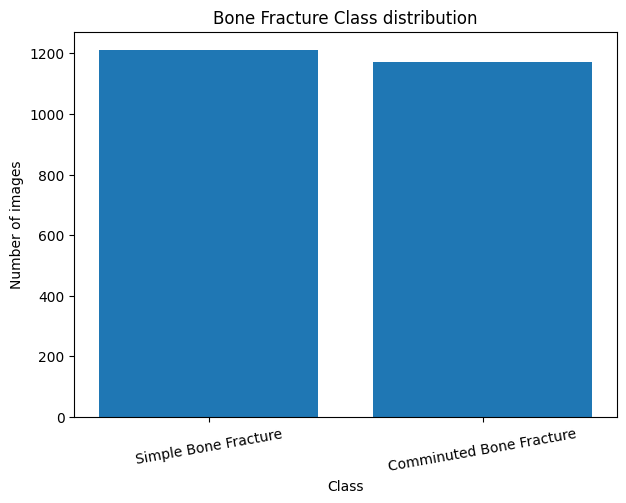

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("Bone Fracture Class distribution")
plt.xticks(rotation=10)
plt.show()

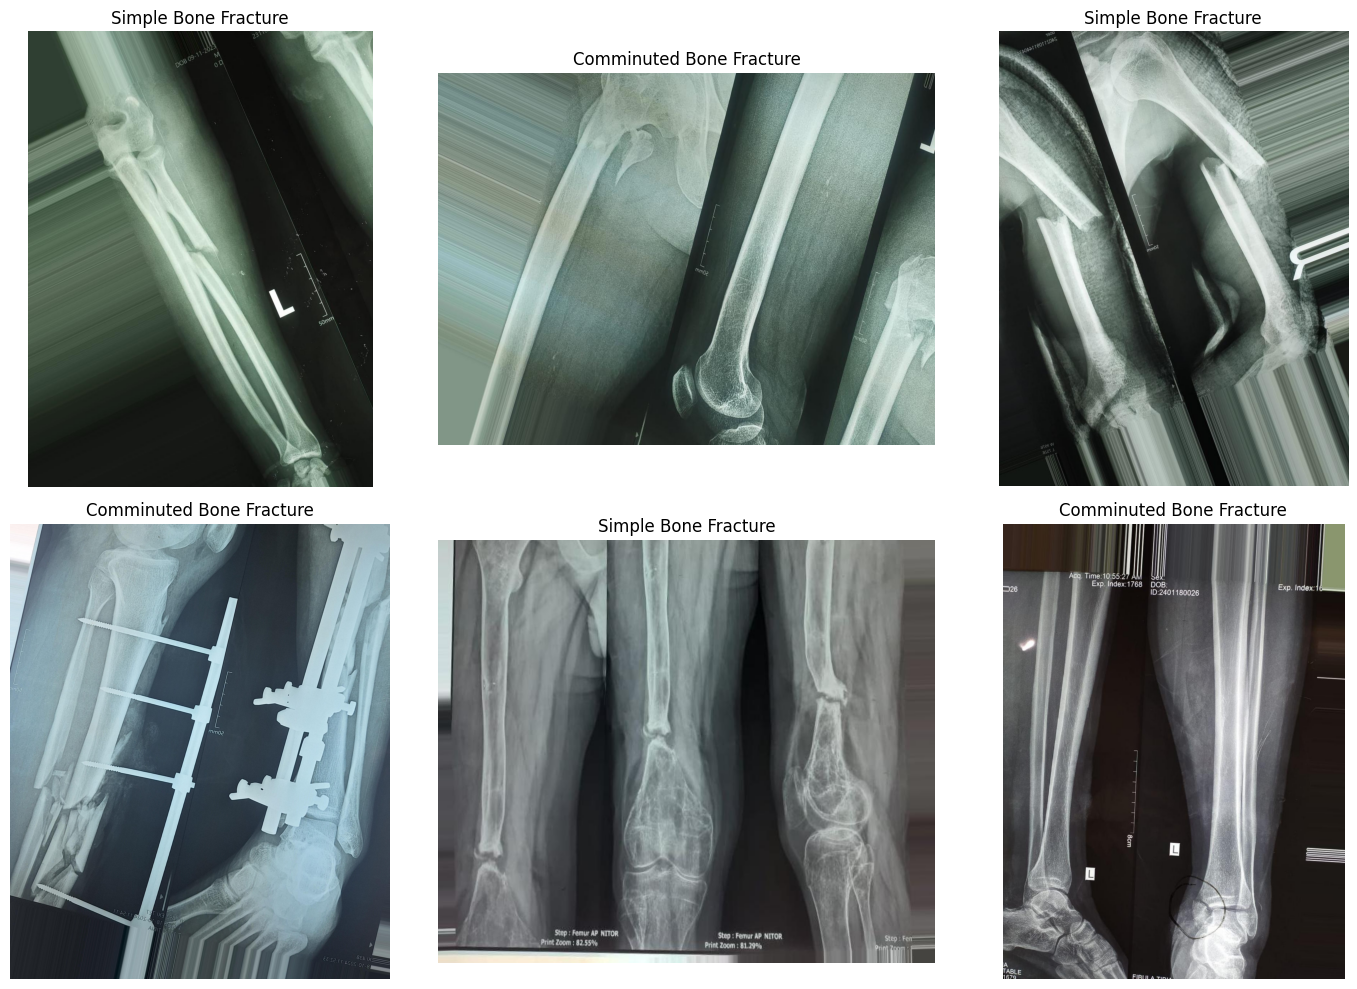

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for ax in axes:
    class_name = random.choice(classes)
    image = random.choice(list(class_name.glob("*.jpg")))
    image = Image.open(image)
    ax.imshow(image)
    ax.set_title(class_name.name)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
print(class_counts)

{'Simple Bone Fracture': 1211, 'Comminuted Bone Fracture': 1173}


In [ ]:
for c in classes:
  print (c)
  print(len(list(c.glob("*"))))

/content/drive/MyDrive/Dissertation/datasets/Bone_fracture_dataset/Original/Simple Bone Fracture
1211
/content/drive/MyDrive/Dissertation/datasets/Bone_fracture_dataset/Original/Comminuted Bone Fracture
1173


**Percentage Distribution**

In [ ]:
for cls, count in class_counts.items():
    percentage = (count / total_images) * 100
print(f"{cls}: {percentage:.2f}%")

Comminuted Bone Fracture: 49.20%


In [ ]:
summary = pd.DataFrame({
    "Class":class_counts.keys(),
    "Images":class_counts.values()
})

summary["Percentage"] =(
    summary["Images"] / summary["Images"].sum()
* 100).round(2)

summary

,Class,Images,Percentage
0,Simple Bone Fracture,1211,50.8
1,Comminuted Bone Fracture,1173,49.2


**Corrupted Images**

In [ ]:
corrupted = []
for cls in classes:
  for image_path in cls.glob("*.jpg"):
    try:
      img = Image.open(image_path)
      img.verify()
    except (IOError, SyntaxError) as e:
      corrupted.append(image_path)
print("corrupted images:", len(corrupted))

corrupted images: 0


# **2.  GRAZPEDWRI-DX DATASET EXPLORATION**

In [ ]:
from pathlib import Path
Graz_path = PROJECT_DIR + "/datasets/GRAZPEDWRI-DX"
part1 = Path(Graz_path + "/images_part1")
image_paths = list(part1.glob("*"))
print("Total images:", len(image_paths))
print("Exists:", part1.exists())

Total images: 5031
Exists: True


In [ ]:
for item in list(part1.iterdir())[:20]:
    print(item)

/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1225_0733873522_01_WRI-L1_F012.png
/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1226_0715562090_01_WRI-L2_F011.png
/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1216_0656675267_01_WRI-R2_F012.png
/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1217_0311468378_01_WRI-R1_F015.png
/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1218_0392258361_05_WRI-R2_M014.png
/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1226_0715562056_01_WRI-L1_F011.png
/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1218_0391565346_04_WRI-R2_M014.png
/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1221_0320157028_01_WRI-L1_F012.png
/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1223_1137875094_01_WRI-L2_F011.png
/content/drive/MyDrive/Dissertation/d

**Check for Duplicates**

In [ ]:
from collections import Counter

filenames = [p.name for p in image_paths]

duplicates = [
    name for name, count in Counter(filenames).items()
    if count > 1
]

print("Duplicate filenames:", len(duplicates))

Duplicate filenames: 0


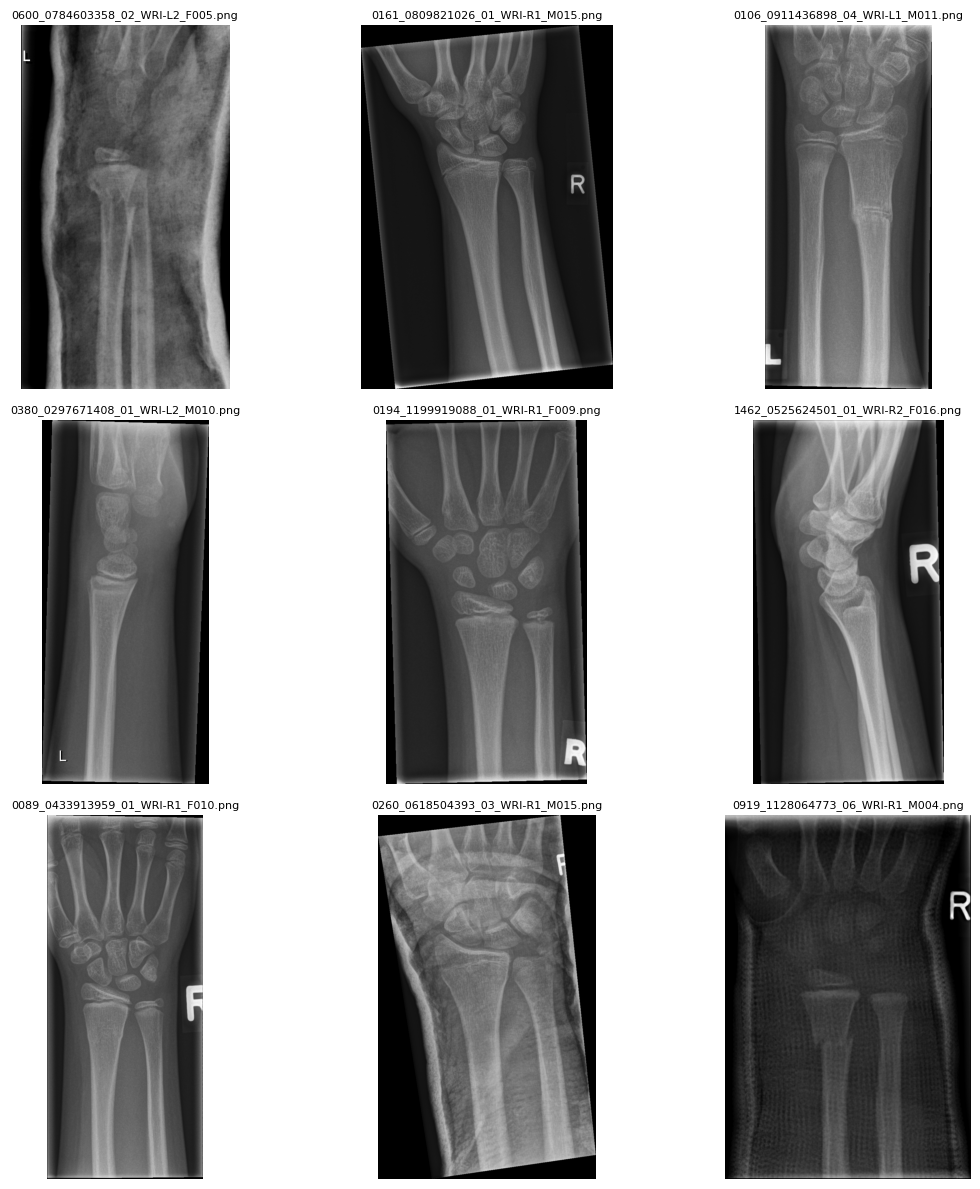

In [ ]:
import random
import matplotlib.pyplot as plt

sample_paths = random.sample(image_paths, 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, path in zip(axes.flatten(), sample_paths):

    img = Image.open(path)

    ax.imshow(img, cmap="gray")
    ax.set_title(path.name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Check the CSV file**

In [ ]:
csv_path = Graz_path + "/dataset.csv"
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

Shape: (20327, 17)

Columns:
['filestem', 'patient_id', 'study_number', 'timehash', 'gender', 'age', 'laterality', 'projection', 'initial_exam', 'ao_classification', 'cast', 'diagnosis_uncertain', 'osteopenia', 'fracture_visible', 'metal', 'pixel_spacing', 'device_manufacturer']

First 5 rows:


,filestem,patient_id,study_number,timehash,gender,age,laterality,projection,initial_exam,ao_classification,cast,diagnosis_uncertain,osteopenia,fracture_visible,metal,pixel_spacing,device_manufacturer
0,0001_1297860395_01_WRI-L1_M014,1,1,1297860395,M,14.1,L,1,1.0,23r-M/2.1,NaN,NaN,NaN,NaN,NaN,0.144,Siemens
1,0001_1297860435_01_WRI-L2_M014,1,1,1297860435,M,14.1,L,2,1.0,23r-M/2.1,NaN,NaN,NaN,1.0,NaN,0.144,Siemens
2,0002_0354485735_01_WRI-R1_F012,2,1,354485735,F,12.0,R,1,1.0,23r-M/2.1,NaN,1.0,NaN,NaN,NaN,0.144,Siemens
3,0002_0354485759_01_WRI-R2_F012,2,1,354485759,F,12.0,R,2,1.0,23r-M/2.1,NaN,1.0,NaN,NaN,NaN,0.144,Siemens
4,0003_0662359226_01_WRI-R1_M011,3,1,662359226,M,11.1,R,1,1.0,23-M/3.1,NaN,NaN,NaN,1.0,NaN,0.144,Siemens


In [ ]:
print(df["fracture_visible"].value_counts(dropna=False))

fracture_visible
1.0    13550
NaN     6777
Name: count, dtype: int64


In [ ]:
print(df["fracture_visible"].unique())

[nan  1.]


In [ ]:
print("Total images:", len(df))
print("Unique patients:", df["patient_id"].nunique())
print("Unique studies:", df["study_number"].nunique())

Total images: 20327
Unique patients: 6091
Unique studies: 12


In [ ]:
print(df["diagnosis_uncertain"].value_counts(dropna=False))


diagnosis_uncertain
NaN    19790
1.0      537
Name: count, dtype: int64


In [ ]:
images_per_patient = df.groupby("patient_id").size()

print(images_per_patient.describe())

count    6091.000000
mean        3.337219
std         2.533628
min         1.000000
25%         2.000000
50%         2.000000
75%         4.000000
max        30.000000
dtype: float64


In [ ]:
print(df["diagnosis_uncertain"].value_counts(dropna=False))


diagnosis_uncertain
NaN    19790
1.0      537
Name: count, dtype: int64


In [ ]:
df = pd.read_csv(csv_path)

# check what fracture_visible actually contains
print(df["fracture_visible"].value_counts(dropna=False))
print(df["filestem"].head())

# check actual image filenames to confirm extension + naming match to filestem
# Corrected: Added closing parenthesis for print and fixed slicing of Path object
print([str(p) for p in part1.iterdir()][:5])

fracture_visible
1.0    13550
NaN     6777
Name: count, dtype: int64
0    0001_1297860395_01_WRI-L1_M014
1    0001_1297860435_01_WRI-L2_M014
2    0002_0354485735_01_WRI-R1_F012
3    0002_0354485759_01_WRI-R2_F012
4    0003_0662359226_01_WRI-R1_M011
Name: filestem, dtype: object
['/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1225_0733873522_01_WRI-L1_F012.png', '/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1226_0715562090_01_WRI-L2_F011.png', '/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1216_0656675267_01_WRI-R2_F012.png', '/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1217_0311468378_01_WRI-R1_F015.png', '/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/1218_0392258361_05_WRI-R2_M014.png']


Filter to images

In [ ]:
import pandas as pd
import os

IMG_DIR = "/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1"

df = pd.read_csv(csv_path)

part1_files = os.listdir(IMG_DIR)
part1_stems = set(os.path.splitext(f)[0] for f in part1_files)

df_part1 = df[df["filestem"].isin(part1_stems)].copy()
print(f"Matched {len(df_part1)} / {len(df)} total rows to images_part1")
print(df_part1["fracture_visible"].value_counts(dropna=False))

Matched 5031 / 20327 total rows to images_part1
fracture_visible
1.0    3334
NaN    1697
Name: count, dtype: int64


In [ ]:
import numpy as np

def row_to_example(row, image_dir=IMG_DIR):
    img_path = os.path.join(image_dir, f"{row['filestem']}.png")

    view = row['projection'] if pd.notna(row['projection']) else ""
    side = row['laterality'] if pd.notna(row['laterality']) else ""
    view_desc = f"{side} {view}".strip() or "wrist"

    findings = []
    has_fracture = pd.notna(row['fracture_visible']) and row['fracture_visible'] == 1.0

    if has_fracture:
        if pd.notna(row.get('ao_classification')):
            findings.append(f"a fracture (AO classification: {row['ao_classification']})")
        else:
            findings.append("a fracture")

    if pd.notna(row.get('osteopenia')) and row['osteopenia'] == 1.0:
        findings.append("osteopenia")
    if pd.notna(row.get('metal')) and row['metal'] == 1.0:
        findings.append("metal hardware")
    if pd.notna(row.get('cast')) and row['cast'] == 1.0:
        findings.append("a cast in place")

    uncertain = pd.notna(row.get('diagnosis_uncertain')) and row['diagnosis_uncertain'] == 1.0

    if findings:
        response = f"This {view_desc} pediatric wrist X-ray shows " + ", ".join(findings) + "."
        if uncertain:
            response += " The diagnosis is noted as uncertain."
    else:
        response = f"This {view_desc} pediatric wrist X-ray shows no fracture or significant abnormality."

    return {
        "image_path": img_path,
        "prompt": "Describe any fracture or abnormal findings in this pediatric wrist X-ray.",
        "response": response,
        "fracture_visible": has_fracture,  # keep for stratified eval later
        "source": "grazpedwri"
    }

examples = df_part1.apply(row_to_example, axis=1).tolist()
print(examples[0])

{'image_path': '/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1/0001_1297860395_01_WRI-L1_M014.png', 'prompt': 'Describe any fracture or abnormal findings in this pediatric wrist X-ray.', 'response': 'This L 1 pediatric wrist X-ray shows no fracture or significant abnormality.', 'fracture_visible': False, 'source': 'grazpedwri'}


In [ ]:
import os

mendeley_root = PROJECT_DIR + "/datasets/Bone_fracture_dataset/Original"
for root, dirs, files in os.walk(mendeley_root):
    print(root)
    print("  dirs:", dirs)
    print("  files sample:", files[:3])

/content/drive/MyDrive/Dissertation/datasets/Bone_fracture_dataset/Original
  dirs: ['Simple Bone Fracture', 'Comminuted Bone Fracture']
  files sample: ['.DS_Store']
/content/drive/MyDrive/Dissertation/datasets/Bone_fracture_dataset/Original/Simple Bone Fracture
  dirs: []
  files sample: ['371_Simple Bone Fracture.jpg', '752_Simple Bone Fracture.jpg', 'IMG_20241102_222206_840.jpg']
/content/drive/MyDrive/Dissertation/datasets/Bone_fracture_dataset/Original/Comminuted Bone Fracture
  dirs: []
  files sample: ['366_Comminuted Bone Fracture.jpg', '346_Comminuted Bone Fracture.jpg', 'IMG-20241105-WA0055.jpg']


Build the HF dataset(lazy image loading)

In [ ]:
from datasets import Dataset
from PIL import Image

grazpedwri_ds = Dataset.from_list(examples)

def load_image(example):
    example["image"] = Image.open(example["image_path"]).convert("RGB")
    return example

# apply lazily at training time rather than eagerly loading 13k+ images into RAM
grazpedwri_ds = grazpedwri_ds.map(load_image, batched=False)  # consider doing this on-the-fly in collate_fn instead for large datasets

Map:   0%|          | 0/5031 [00:00<?, ? examples/s]

Mendeley conversion code

In [ ]:
import os

MENDELEY_ROOT = "/content/drive/MyDrive/Dissertation/datasets/Bone_fracture_dataset/Original"

FRACTURE_TYPES = {
    "Simple Bone Fracture": "a simple (non-displaced) bone fracture",
    "Comminuted Bone Fracture": "a comminuted bone fracture, where the bone is broken into multiple fragments"
}

def build_mendeley_examples(root=MENDELEY_ROOT):
    examples = []
    for folder_name, description in FRACTURE_TYPES.items():
        folder_path = os.path.join(root, folder_name)
        for fname in os.listdir(folder_path):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            examples.append({
                "image_path": os.path.join(folder_path, fname),
                "prompt": "Describe any fracture or abnormal findings in this X-ray.",
                "response": f"This X-ray shows evidence of {description}.",
                "fracture_visible": True,
                "source": "mendeley"
            })
    return examples

mendeley_examples = build_mendeley_examples()
print(f"Total Mendeley examples: {len(mendeley_examples)}")
print(mendeley_examples[0])

Merge the two dataset into one HF dataset


In [ ]:
from datasets import Dataset, concatenate_datasets

mendeley_ds = Dataset.from_list(mendeley_examples)
grazpedwri_ds = Dataset.from_list(examples)  # from the earlier GRAZPEDWRI-DX step

full_ds = concatenate_datasets([mendeley_ds, grazpedwri_ds]).shuffle(seed=42)

print(full_ds)
print(full_ds["source"][:5])

# check class balance across the merged set
import pandas as pd
pd.Series(full_ds["fracture_visible"]).value_counts()

Dataset({
    features: ['image_path', 'prompt', 'response', 'fracture_visible', 'source'],
    num_rows: 7415
})
['grazpedwri', 'grazpedwri', 'grazpedwri', 'grazpedwri', 'grazpedwri']


,count
True,5718
False,1697


In [ ]:
import os

base = "/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX"
print(os.listdir(base))

# check sizes to confirm they uploaded fully, not partially
for f in ["images_part2.zip", "images_part3.zip", "images_part4.zip"]:
    path = os.path.join(base, f)
    if os.path.exists(path):
        size_gb = os.path.getsize(path) / (1024**3)
        print(f"{f}: {size_gb:.2f} GB")
    else:
        print(f"{f}: NOT FOUND")

['dataset.csv', 'images_part1', 'images_part2.zip', 'images_part3.zip', 'images_part4.zip']
images_part2.zip: 3.84 GB
images_part3.zip: 3.59 GB
images_part4.zip: 3.92 GB


In [ ]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   25G   84G  23% /


Extract image_part2 to image_part4


In [ ]:
import zipfile, os

base = "/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX"
parts = ["images_part2", "images_part3", "images_part4"]

for part in parts:
    zip_path = f"{base}/{part}.zip"
    extract_path = f"/content/{part}"
    if not os.path.exists(extract_path):
        print(f"Extracting {part}...")
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(extract_path)
        print(f"Done: {part}")
    else:
        print(f"{part} already extracted, skipping")

Extracting images_part2...
Done: images_part2
Extracting images_part3...
Done: images_part3
Extracting images_part4...
Done: images_part4




verify number of grazpedwr-dx


In [ ]:
import os

parts = ["images_part1", "images_part2", "images_part3", "images_part4"]
base_content = "/content"

total = 0
for part in parts:
    # part1 lives on Drive, parts 2-4 were extracted to /content
    if part == "images_part1":
        path = "/content/drive/MyDrive/Dissertation/datasets/GRAZPEDWRI-DX/images_part1"
    else:
        path = f"/content/{part}"
    n = len(os.listdir(path))
    print(f"{part}: {n} files")
    total += n

print(f"\nTotal images: {total}")

images_part1: 5031 files
images_part2: 5143 files
images_part3: 4842 files
images_part4: 5311 files

Total images: 20327
